In [24]:
import pandas as pd

df = pd.read_csv('/content/amazon_prime_titles.csv')

print(df.shape)
df.head()

(9668, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,The Grand Seduction,Don McKellar,"Brendan Gleeson, Taylor Kitsch, Gordon Pinsent",Canada,"March 30, 2021",2014,NaN,113 min,"Comedy, Drama",A small fishing village must procure a local d...
1,s2,Movie,Take Care Good Night,Girish Joshi,"Mahesh Manjrekar, Abhay Mahajan, Sachin Khedekar",India,"March 30, 2021",2018,13+,110 min,"Drama, International",A Metro Family decides to fight a Cyber Crimin...
2,s3,Movie,Secrets of Deception,Josh Webber,"Tom Sizemore, Lorenzo Lamas, Robert LaSardo, R...",United States,"March 30, 2021",2017,NaN,74 min,"Action, Drama, Suspense",After a man discovers his wife is cheating on ...
3,s4,Movie,Pink: Staying True,Sonia Anderson,"Interviews with: Pink, Adele, Beyoncé, Britney...",United States,"March 30, 2021",2014,NaN,69 min,Documentary,"Pink breaks the mold once again, bringing her ..."
4,s5,Movie,Monster Maker,Giles Foster,"Harry Dean Stanton, Kieran O'Brien, George Cos...",United Kingdom,"March 30, 2021",1989,NaN,45 min,"Drama, Fantasy",Teenage Matt Banting wants to work with a famo...


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9668 entries, 0 to 9667
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       9668 non-null   object
 1   type          9668 non-null   object
 2   title         9668 non-null   object
 3   director      7585 non-null   object
 4   cast          8435 non-null   object
 5   country       672 non-null    object
 6   date_added    155 non-null    object
 7   release_year  9668 non-null   int64 
 8   rating        9331 non-null   object
 9   duration      9668 non-null   object
 10  listed_in     9668 non-null   object
 11  description   9668 non-null   object
dtypes: int64(1), object(11)
memory usage: 906.5+ KB


In [26]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2083
cast,1233
country,8996
date_added,9513
release_year,0
rating,337
duration,0


In [27]:
df.fillna("Unknown", inplace=True)

print(df.shape)

(9668, 12)


In [28]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col].astype(str))

In [29]:
X = df.drop('type', axis=1)
y = df['type']

print(X.shape)
print(y.shape)

(9668, 11)
(9668,)


In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(7734, 11)
(1934, 11)


In [31]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9953464322647363


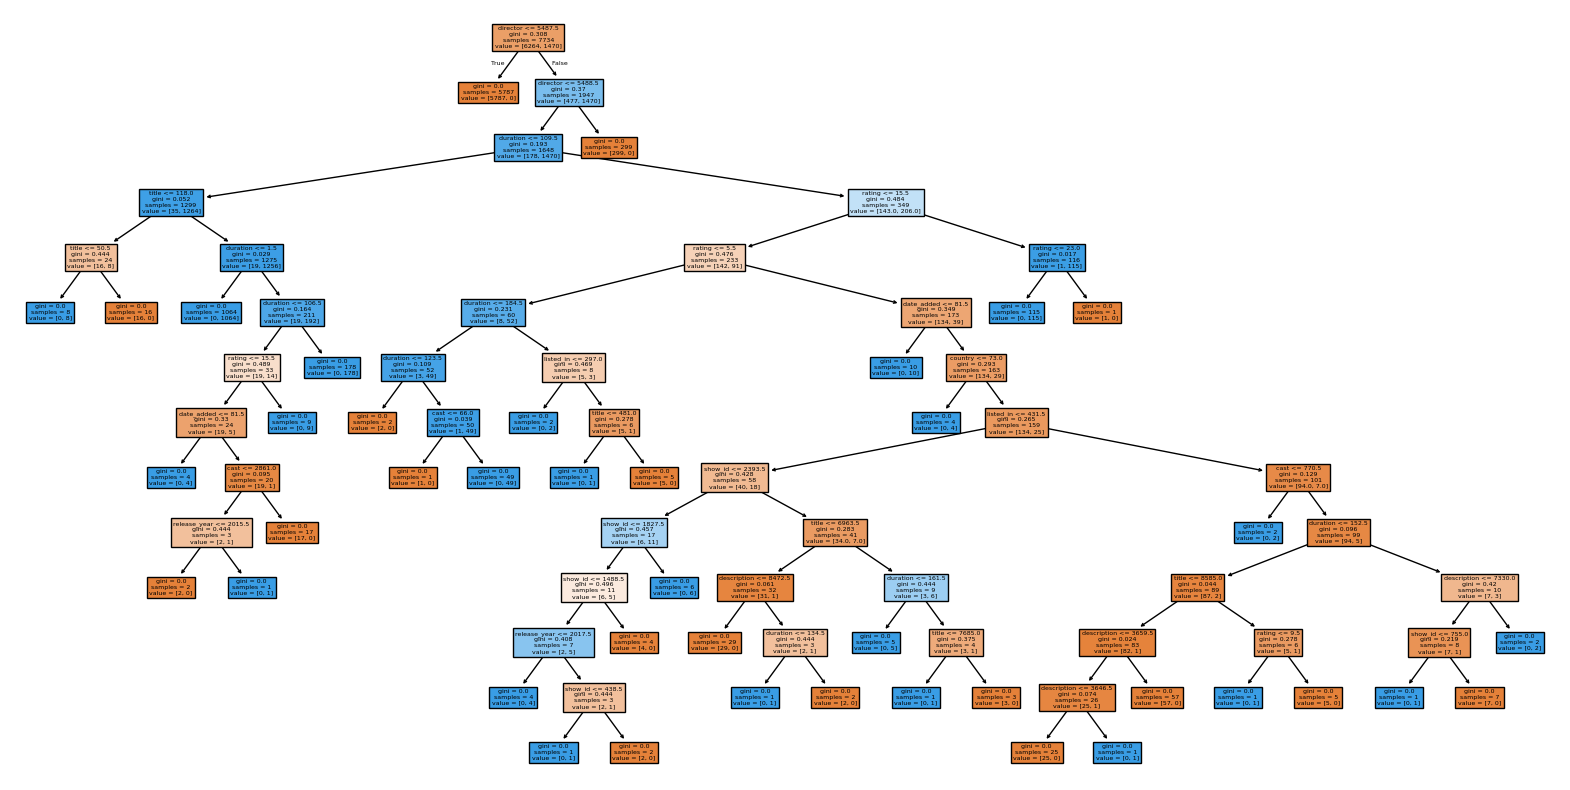

In [32]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))

plot_tree(
    dt,
    filled=True,
    feature_names=X.columns
)

plt.show()

In [34]:
dt_depth = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt_depth.fit(X_train, y_train)

pred_depth = dt_depth.predict(X_test)

print(
    "Accuracy with max_depth=5:",
    accuracy_score(y_test, pred_depth)
)

Accuracy with max_depth=5: 0.9891416752843847


In [35]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(
    "Random Forest Accuracy:",
    accuracy_score(y_test, y_pred_rf)
)

Random Forest Accuracy: 0.9968976215098242


In [36]:
print("Decision Tree Accuracy:",
      accuracy_score(y_test, y_pred_dt))

print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf))

Decision Tree Accuracy: 0.9953464322647363
Random Forest Accuracy: 0.9968976215098242


In [37]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(10)

,Feature,Importance
2,director,0.421964
8,duration,0.373600
7,rating,0.088931
9,listed_in,0.029015
5,date_added,0.022559
0,show_id,0.019934
1,title,0.014002
6,release_year,0.012241
3,cast,0.009886
10,description,0.006561


In [38]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(10)

,Feature,Importance
2,director,0.421964
8,duration,0.373600
7,rating,0.088931
9,listed_in,0.029015
5,date_added,0.022559
0,show_id,0.019934
1,title,0.014002
6,release_year,0.012241
3,cast,0.009886
10,description,0.006561


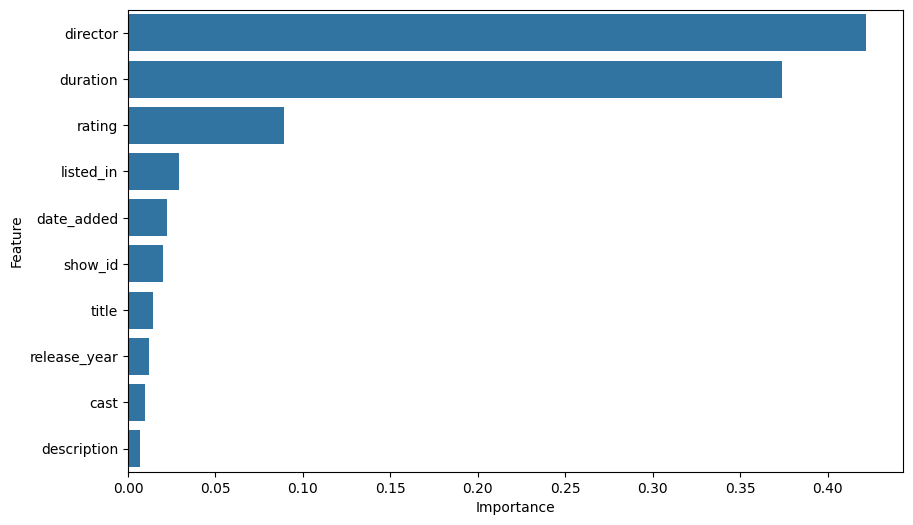

In [39]:
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(10)
)

plt.show()

In [40]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf,
    X,
    y,
    cv=5
)

print("Cross Validation Scores:")
print(scores)

print("Average Accuracy:")
print(scores.mean())

Cross Validation Scores:
[0.97207859 0.94881075 0.98862461 0.99120538 0.99586136]
Average Accuracy:
0.9793161392694565
